In [1]:
!pip3 install openslide-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 1.3 MB/s eta 0:00:00a 0:00:01
  Created wheel for openslide-python: filename=openslide_python-1.3.1-cp313-cp313-macosx_11_0_arm64.whl size=26253 sha256=5da32a4d61d2cbe2b484a54fca4014d94ede242e6e80da85c90b130b47472f90
  Stored in directory: /Users/lexuanthang/Library/Caches/pip/wheels/ff/37/14/df0eb2218a0d60de5593499dab734477a3740a629263376a79
Successfully built openslide-python


In [4]:
# you need install openslide before add the file
# The path can also be read from a config file, etc.
OPENSLIDE_PATH = r'D:\DATA CHUNG\SETUP\openslide-win64-20231011\bin\.'

import os
if hasattr(os, 'add_dll_directory'):
    # Windows
    with os.add_dll_directory(OPENSLIDE_PATH):
        import openslide
else:
    import openslide

In [5]:
import os
from PIL import Image, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Replace the path below with the path to your .ndpi file
ndpi_file_path = '..\\Data\\BALF\\2019-08-06 11.54.15.ndpi'

# Path where the images will be saved
output_dir = '..\\Data\\Labeling\P02'

# Make sure that the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Open the .ndpi file using OpenSlide
slide = openslide.OpenSlide(ndpi_file_path)

# Determine the size of the region you want to extract
region_width = 1024
region_height = 1024

# Calculate the number of regions to extract based on the slide dimensions
dims = slide.dimensions
n_cols = dims[0] // region_width
n_rows = dims[1] // region_height

# Loop over the entire slide, extracting regions
for row in range(n_rows):
    for col in range(n_cols):
        # Calculate the start position for this region
        start_x = col * region_width
        start_y = row * region_height

        # Extract the region from the highest resolution level
        region = slide.read_region((start_x, start_y), 0, (region_width, region_height))

        # Convert to an RGB image (discard the alpha channel)
        region_image = region.convert("RGB")

        # Save the region to a file
        image_name = f"P01_{row}_{col}.png"
        region_image.save(os.path.join(output_dir, image_name))

# Close the slide to release the file
slide.close()

print(f"Extracted {n_rows * n_cols} regions.")

Extracted 784 regions.


Filtering the empty image

P01_0_0.png: 97.80% white
P01_0_1.png: 98.66% white
P01_0_10.png: 96.50% white
P01_0_11.png: 98.48% white
P01_0_12.png: 96.10% white
P01_0_13.png: 97.70% white
P01_0_14.png: 96.85% white
P01_0_15.png: 97.46% white
P01_0_16.png: 87.95% white
P01_0_17.png: 97.61% white
P01_0_18.png: 96.22% white
P01_0_19.png: 95.25% white
P01_0_2.png: 97.53% white
P01_0_20.png: 95.36% white
P01_0_21.png: 98.59% white
P01_0_22.png: 98.44% white
P01_0_23.png: 98.07% white
P01_0_24.png: 93.53% white
P01_0_25.png: 95.28% white
P01_0_26.png: 97.98% white
P01_0_27.png: 96.64% white
P01_0_3.png: 97.25% white
P01_0_4.png: 97.61% white
P01_0_5.png: 98.62% white
P01_0_6.png: 96.94% white
P01_0_7.png: 96.81% white
P01_0_8.png: 96.21% white
P01_0_9.png: 97.42% white
P01_10_0.png: 97.55% white
P01_10_1.png: 99.13% white
P01_10_10.png: 13.78% white
P01_10_11.png: 12.26% white
P01_10_12.png: 14.00% white
P01_10_13.png: 32.89% white
P01_10_14.png: 12.32% white
P01_10_15.png: 60.98% white
P01_10_16.png: 20.31% white
P01_

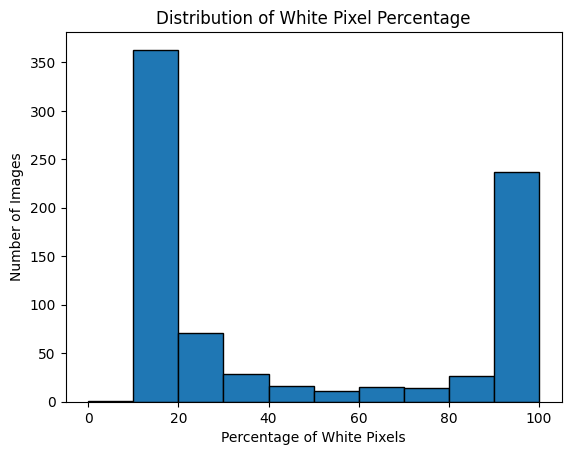

In [11]:
# Define the directory where the images are located
output_dir = '..\\Data\\Labeling\P02'

# Function to calculate the percentage of white pixels in an image
def calculate_white_percentage(image_path):
    # Open the image and convert it to grayscale
    image = Image.open(image_path).convert('L')
    
    image = ImageEnhance.Contrast(image)
    
    image = image.enhance(10)
    
    # Convert the image to a numpy array
    image_array = np.array(image)
    
    # Calculate the total number of pixels
    total_pixels = image_array.size
    
    # Count the number of white pixels (assuming white is 255)
    white_pixels = np.sum(image_array == 255)
    # Calculate the percentage of white pixels
    white_percentage = 100 - (white_pixels / total_pixels) * 100
    return white_percentage

# Dictionary to hold the image file names and their corresponding white percentage
white_percentage_dict = {}

# Loop through all the files in the directory
for file_name in os.listdir(output_dir):
    # Construct the full file path
    file_path = os.path.join(output_dir, file_name)
    # Check if the file is an image
    if file_path.lower().endswith('.png'):
        # Calculate the white percentage
        white_percentage = calculate_white_percentage(file_path)
        # Add to the dictionary
        white_percentage_dict[file_name] = white_percentage

# Output the white percentage of each image
white_percentages = []
for file_name, white_percentage in white_percentage_dict.items():
    white_percentages.append(white_percentage)
    print(f"{file_name}: {white_percentage:.2f}% white")
    
# Create a histogram
plt.hist(white_percentages, bins=10, range=(0, 100), edgecolor='black')
plt.xlabel('Percentage of White Pixels')
plt.ylabel('Number of Images')
plt.title('Distribution of White Pixel Percentage')
plt.show()

Remove empty picture

In [12]:
# Optionally, filter and delete images with more than 80% white space
threshold = 60  # Define your threshold here
for file_name, white_percentage in white_percentage_dict.items():
    if white_percentage > threshold:
        # Construct the full file path
        file_path = os.path.join(output_dir, file_name)
        # Delete the file
        os.remove(file_path)
        print(f"Deleted {file_name} with {white_percentage:.2f}% white space")

Deleted P01_0_0.png with 97.80% white space
Deleted P01_0_1.png with 98.66% white space
Deleted P01_0_10.png with 96.50% white space
Deleted P01_0_11.png with 98.48% white space
Deleted P01_0_12.png with 96.10% white space
Deleted P01_0_13.png with 97.70% white space
Deleted P01_0_14.png with 96.85% white space
Deleted P01_0_15.png with 97.46% white space
Deleted P01_0_16.png with 87.95% white space
Deleted P01_0_17.png with 97.61% white space
Deleted P01_0_18.png with 96.22% white space
Deleted P01_0_19.png with 95.25% white space
Deleted P01_0_2.png with 97.53% white space
Deleted P01_0_20.png with 95.36% white space
Deleted P01_0_21.png with 98.59% white space
Deleted P01_0_22.png with 98.44% white space
Deleted P01_0_23.png with 98.07% white space
Deleted P01_0_24.png with 93.53% white space
Deleted P01_0_25.png with 95.28% white space
Deleted P01_0_26.png with 97.98% white space
Deleted P01_0_27.png with 96.64% white space
Deleted P01_0_3.png with 97.25% white space
Deleted P01_0_